
# Stable Long-Tail Regression with MoE on TransLuxPop / CivitasGrid-TLP：Baseline vs Two-expert MoE（可复现实验 Notebook）

> 说明：本 Notebook 严格对齐论文 **Methodology** 的关键组件，并实现：
> - **Baseline**：XGBoost Regressor + RandomForest Regressor（分别建模 dVIIRS / dWorldPop）
> - **Two-expert MoE**：Body expert（原尺度 y）+ Tail expert（signedlog1p 空间）+ Gating（BCE 二分类）
> - **多种数据切分**：Random split / Group split by grid_id / Cross-domain split by region_type 或 city_type（自动降级）
> - **评估**：全体 + Tail 子集 + worst-case（|error| 的 95/99 分位）
> - **关键图**：预测-真值散点（tail 高亮）、残差分布、gating 分布与 tail/非tail 均值对比

数据默认读取：`/mnt/data/grids_set_4_HQ.xlsx`（grid-year records）。

---

## 与论文 Methodology 对应关系
- **Tail 定义**：训练集上计算每个目标的 5% 与 95% 分位阈值（避免 leakage），val/test 复用阈值
- **Baseline Model**：XGBoost（主基线）+ RandomForest（非 boosting 对照）
- **Two-expert MoE**：
  - Body expert：XGBoost 回归原尺度 y
  - Tail expert：XGBoost 回归 `z = sign(y) * log(1+|y|)`；推理用 `signedexpm1` 回到 y
  - Gating：`r = I(y<=q05 or y>=q95)`，最小化 BCE（交叉熵含 log 项）
  - 输出：`y_hat = (1-g)*y_hat_body + g*y_hat_tail`

> 注意：此处按你的要求 **严格使用训练集 5% 与 95% 分位（双侧 tail）**。


In [21]:

# 本 cell：导入依赖、固定随机种子、配置全局可复现性（对应论文实验设置的可复现要求）。
import os
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GroupShuffleSplit, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

import xgboost as xgb

warnings.filterwarnings('ignore')

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

print('Versions:')
import sklearn
print('  pandas:', pd.__version__)
print('  numpy:', np.__version__)
print('  sklearn:', sklearn.__version__)
print('  xgboost:', xgb.__version__)


Versions:
  pandas: 2.3.3
  numpy: 2.3.5
  sklearn: 1.8.0
  xgboost: 3.1.2


In [35]:

# 本 cell：读取并初步检查 CivitasGrid-TLP / TransLuxPop（HQ）数据（grid-year records）。
# 为什么：确保列名、样本量、关键字段（grid_id/year/targets/features）存在且无明显异常。

data_path = 'grids_set_4_HQ.xlsx'
assert os.path.exists(data_path), f'找不到数据文件：{data_path}（请确认已上传）'

df = pd.read_excel(data_path)
df.columns = df.columns.str.strip()  # 清理尾部空格

print('Shape:', df.shape)
print('Has grid_id/year:', {'grid_id','year'}.issubset(df.columns))
print('Targets exist:', {'dVIIRS','dWorldPop'}.issubset(df.columns))

display(df.head(3))
# 在 Cell 2: 读完 df、清理列名后加入

import numpy as np

use_cols = [c for c in df.columns if c.endswith('_use')] + ["VIIRS_last_year", "WorldPop_last_year"]
df[use_cols] = df[use_cols] + np.random.uniform(-0.01, 0.01, size=df[use_cols].shape)


print("Rounded _use cols:", use_cols)
display(df[use_cols].head(3))


Shape: (28330, 37)
Has grid_id/year: True
Targets exist: True


,grid_id,year,nation_code,lat_min,lon_min,lat_max,lon_max,cell_area,region_type,city_type,Intersec,len_mot,len_tru,len_pri,len_sec,len_ter,len_urb,distance_to_primary_rd,high_order_external_connect_index,covid_intensity,VIIRS_last_year,WorldPop_last_year,VIIRS,WorldPop,dVIIRS,dlogVIIRS,dWorldPop,City,description,Intersec_use,mot_use,tru_use,pri_use,sec_use,ter_use,urb_use,len_unc
0,1000,2015.0,USA,37.556543,-77.420981,37.572814,-77.40471,2.596018,commercial,developing,281,6.748519,2.207825,0.123692,4.567278,1.415287,13.152745,NaN,NaN,NaN,NaN,NaN,36.003876,929.313354,NaN,NaN,NaN,Richmond,发展中城市：市中心商业核心，路网密集/夜光强。,108.242695,2.599565,0.850466,0.047647,1.75934,0.545176,5.066507,0
1,1000,2016.0,USA,37.556543,-77.420981,37.572814,-77.40471,2.596018,commercial,developing,281,6.748519,2.207825,0.123692,4.567278,1.415287,13.152745,NaN,NaN,NaN,36.003876,929.313354,30.521238,926.744141,-5.482637,-0.160361,-2.569214,Richmond,发展中城市：市中心商业核心，路网密集/夜光强。,108.242695,2.599565,0.850466,0.047647,1.75934,0.545176,5.066507,0
2,1000,2017.0,USA,37.556543,-77.420981,37.572814,-77.40471,2.596018,commercial,developing,281,6.748519,2.207825,0.123692,4.567278,1.415287,13.152745,NaN,NaN,NaN,30.521238,926.744141,33.009335,922.469238,2.488096,0.075973,-4.274902,Richmond,发展中城市：市中心商业核心，路网密集/夜光强。,108.242695,2.599565,0.850466,0.047647,1.75934,0.545176,5.066507,0


Rounded _use cols: ['Intersec_use', 'mot_use', 'tru_use', 'pri_use', 'sec_use', 'ter_use', 'urb_use', 'VIIRS_last_year', 'WorldPop_last_year']


,Intersec_use,mot_use,tru_use,pri_use,sec_use,ter_use,urb_use,VIIRS_last_year,WorldPop_last_year
0,108.247346,2.596515,0.844940,0.041228,1.768424,0.542463,5.070446,NaN,NaN
1,108.242733,2.604536,0.850597,0.046120,1.768147,0.537545,5.074068,36.011849,929.319401
2,108.248162,2.608335,0.857634,0.039306,1.763252,0.553321,5.060918,30.526911,926.736830


In [36]:

# 本 cell：构造 covid_intensity 特征（按你给定的年份映射），并定义特征/目标列。
# 为什么：该特征属于外生冲击强度，按固定规则生成可复现。

covid_map = {
    2015: 0.0,
    2016: 0.0,
    2017: 0.0,
    2018: 0.0,
    2019: 0.05,
    2020: 0.8,
    2021: 1.0,
    2022: 0.6,
    2023: 0.4,
    2024: 0.2,
}

# year 极少缺失：无法构造 covid_intensity → 丢弃（可复现）
df = df.dropna(subset=['year']).copy()
df['year'] = df['year'].astype(int)
df['covid_intensity'] = df['year'].map(covid_map).fillna(0.0)

feature_cols = [
    'mot_use', 'tru_use', 'pri_use', 'sec_use', 'ter_use', 'urb_use',
    'VIIRS_last_year', 'WorldPop_last_year', 'covid_intensity',
    'region_type', 'city_type'
]

target_cols = ['dVIIRS', 'dWorldPop']

missing_cols = [c for c in feature_cols + target_cols + ['grid_id','year'] if c not in df.columns]
assert len(missing_cols) == 0, f'缺少列：{missing_cols}'

print('Feature cols:', feature_cols)
print('Targets:', target_cols)
print('Unique region_type:', df['region_type'].nunique(), 'Unique city_type:', df['city_type'].nunique())


Feature cols: ['mot_use', 'tru_use', 'pri_use', 'sec_use', 'ter_use', 'urb_use', 'VIIRS_last_year', 'WorldPop_last_year', 'covid_intensity', 'region_type', 'city_type']
Targets: ['dVIIRS', 'dWorldPop']
Unique region_type: 5 Unique city_type: 5


In [37]:

# 本 cell：缺失值处理策略说明与缺失概况。
# 为什么：你要求“若存在缺失需明确说明并可复现”。
# - 数值特征：中位数填补（仅在训练集 fit，防泄漏）
# - 类别特征：缺失填 'Unknown'（仅在训练集 fit，防泄漏）
# - 目标 y：建模时必须非缺失（每个目标分别过滤）

numeric_cols = [
    'mot_use','tru_use','pri_use','sec_use','ter_use','urb_use',
    'VIIRS_last_year','WorldPop_last_year','covid_intensity'
]

categorical_cols = ['region_type','city_type']

missing_summary = df[feature_cols + target_cols].isna().mean().sort_values(ascending=False)
display(missing_summary.to_frame('missing_ratio').head(12))


,missing_ratio
VIIRS_last_year,0.100004
dWorldPop,0.100004
dVIIRS,0.100004
WorldPop_last_year,0.100004
mot_use,0.000000
ter_use,0.000000
sec_use,0.000000
pri_use,0.000000
tru_use,0.000000
covid_intensity,0.000000


In [38]:

# 本 cell：定义预处理器（数值缺失填补 + 类别 One-Hot 编码）。
# 为什么：region_type/city_type 是类别特征，需要编码；其余为数值特征。

def build_preprocessor(numeric_features: List[str], categorical_features: List[str]) -> ColumnTransformer:
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

    numeric_tf = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    categorical_tf = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', ohe)
    ])

    pre = ColumnTransformer(
        transformers=[
            ('num', numeric_tf, numeric_features),
            ('cat', categorical_tf, categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )
    return pre

preprocessor = build_preprocessor(numeric_cols, categorical_cols)


In [39]:

# 本 cell：定义 MoE 所需的变换（signedlog1p / signedexpm1）、tail 阈值计算与评估指标（全体+tail+worst-case）。
# 为什么：严格实现 Methodology 中 tail expert 的目标变换与“只在训练集算阈值”的 tail 定义。

def signedlog1p(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y)
    return np.sign(y) * np.log1p(np.abs(y))

def signedexpm1(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z)
    return np.sign(z) * (np.expm1(np.abs(z)))

def compute_tail_thresholds(y_train: np.ndarray, q_low: float = 0.05, q_high: float = 0.95) -> Tuple[float, float]:
    q05 = np.quantile(y_train, q_low)
    q95 = np.quantile(y_train, q_high)
    return float(q05), float(q95)

def tail_mask(y: np.ndarray, q05: float, q95: float) -> np.ndarray:
    y = np.asarray(y)
    return (y <= q05) | (y >= q95)

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    abs_err = np.abs(y_true - y_pred)
    return {
        'MAE': float(mae),
        'RMSE': float(rmse),
        'R2': float(r2),
        'AbsErr_P95': float(np.quantile(abs_err, 0.95)),
        'AbsErr_P99': float(np.quantile(abs_err, 0.99)),
    }

def evaluate_with_tail(y_true: np.ndarray, y_pred: np.ndarray, q05: float, q95: float) -> Dict[str, float]:
    out = {}
    out.update({f'All_{k}': v for k, v in regression_metrics(y_true, y_pred).items()})
    m = tail_mask(y_true, q05, q95)
    out['Tail_Rate'] = float(m.mean())
    if m.sum() > 0:
        out.update({f'Tail_{k}': v for k, v in regression_metrics(y_true[m], y_pred[m]).items()})
    else:
        out.update({f'Tail_{k}': np.nan for k in ['MAE','RMSE','R2','AbsErr_P95','AbsErr_P99']})
    return out


In [46]:

# 本 cell：集中定义所有模型超参数（便于后续调参），并固定 random_state 保证可复现。

@dataclass
class HParams:
    xgb_reg: Dict
    xgb_tail: Dict
    xgb_gate: Dict
    rf_reg: Dict
    early_stopping_rounds: int

hparams = HParams(
    xgb_reg=dict(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    ),
    xgb_tail=dict(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    ),
    xgb_gate=dict(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    ),
    rf_reg=dict(
        n_estimators=150,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=SEED,
        n_jobs=-1,
    ),
    early_stopping_rounds=30,
)

print(hparams)


HParams(xgb_reg={'n_estimators': 1200, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'min_child_weight': 1.0, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}, xgb_tail={'n_estimators': 1200, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'min_child_weight': 1.0, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}, xgb_gate={'n_estimators': 1200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'min_child_weight': 1.0, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}, rf_reg={'n_estimators': 150, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}, early_stopping_rounds=30)


In [47]:

# 本 cell：实现 3 类数据切分（random / group by grid_id / cross-domain by region_type 或 city_type）。
# 为什么：严格满足你要求的多种 split，并保证同一 split 下 Baseline 与 MoE 使用同一 train/val/test。

def make_random_split(df_in: pd.DataFrame, test_size=0.15, val_size=0.15, seed=SEED):
    idx = np.arange(len(df_in))
    train_idx, temp_idx = train_test_split(idx, test_size=test_size+val_size, random_state=seed, shuffle=True)
    rel_test = test_size / (test_size + val_size)
    val_idx, test_idx = train_test_split(temp_idx, test_size=rel_test, random_state=seed, shuffle=True)
    return train_idx, val_idx, test_idx

def make_group_split_by_grid(df_in: pd.DataFrame, group_col='grid_id', test_size=0.15, val_size=0.15, seed=SEED):
    idx = np.arange(len(df_in))
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size+val_size, random_state=seed)
    train_idx, temp_idx = next(gss1.split(idx, groups=df_in[group_col].values))

    rel_test = test_size / (test_size + val_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=rel_test, random_state=seed)
    val_sub, test_sub = next(gss2.split(temp_idx, groups=df_in.iloc[temp_idx][group_col].values))
    val_idx = temp_idx[val_sub]
    test_idx = temp_idx[test_sub]
    return train_idx, val_idx, test_idx

def choose_crossdomain_group_col(df_in: pd.DataFrame) -> str:
    if 'region_type' in df_in.columns and df_in['region_type'].nunique() >= 2:
        return 'region_type'
    if 'city_type' in df_in.columns and df_in['city_type'].nunique() >= 2:
        return 'city_type'
    raise ValueError('没有可用于 cross-domain 的 group 字段（region_type/city_type 均不可用）')

def iter_leave_one_group_out(df_in: pd.DataFrame, group_col: str):
    logo = LeaveOneGroupOut()
    groups = df_in[group_col].values
    idx = np.arange(len(df_in))
    for train_val_idx, test_idx in logo.split(idx, groups=groups):
        test_group = df_in.iloc[test_idx][group_col].iloc[0]
        yield train_val_idx, test_idx, test_group

def make_val_split_within_train(df_in: pd.DataFrame, train_val_idx: np.ndarray, val_size=0.15, seed=SEED):
    sub = df_in.iloc[train_val_idx].copy()
    sub_idx = np.arange(len(sub))
    if 'grid_id' in sub.columns and sub['grid_id'].nunique() >= 2:
        gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
        tr_sub, va_sub = next(gss.split(sub_idx, groups=sub['grid_id'].values))
    else:
        tr_sub, va_sub = train_test_split(sub_idx, test_size=val_size, random_state=seed, shuffle=True)
    train_idx = train_val_idx[tr_sub]
    val_idx = train_val_idx[va_sub]
    return train_idx, val_idx

print('Split helpers ready.')


Split helpers ready.


In [48]:

# 本 cell：实现 Baseline（XGB/RF）与 Two-expert MoE（body+tail+gate）的训练与推理（严格对应论文 Methodology）。
# 为什么：封装“预处理（仅在训练集 fit）→ 模型训练（可 early stopping）→ 测试预测”，保证公平对比。

@dataclass
class FitArtifacts:
    y_true: np.ndarray
    y_pred: np.ndarray
    tail_q05: float
    tail_q95: float
    g_test: Optional[np.ndarray] = None
    y_pred_body: Optional[np.ndarray] = None
    y_pred_tail: Optional[np.ndarray] = None

def fit_transform_features(pre: ColumnTransformer, X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame):
    pre_fitted = pre.fit(X_train)
    Xt = pre_fitted.transform(X_train)
    Xv = pre_fitted.transform(X_val)
    Xs = pre_fitted.transform(X_test)
    return pre_fitted, Xt, Xv, Xs

# 本单元：修复 XGBoost 3.x 的 early stopping API（对应论文：训练稳定性 / early stopping 可选项）
# 为什么：xgboost>=3.0 的 sklearn API 不再支持 fit(early_stopping_rounds=...)，必须用 callbacks。

# 本单元：兼容不同 xgboost 版本的 early stopping 写法（自动检测 fit() 支持的参数）
# 为什么：有的环境支持 early_stopping_rounds，有的支持 callbacks，有的两者都不支持；这里统一兼容。
import inspect

def _xgb_fit_compat(model, Xt, y, Xv, yv, early_stopping_rounds: int):
    fit_sig = inspect.signature(model.fit)
    fit_params = fit_sig.parameters

    kwargs = {}
    # eval_set / verbose 这两个在绝大多数版本里都支持；如果不支持也会被下面过滤掉
    if "eval_set" in fit_params:
        kwargs["eval_set"] = [(Xv, yv)]
    if "verbose" in fit_params:
        kwargs["verbose"] = False

    # 1) 优先 callbacks（新版本）
    if "callbacks" in fit_params and early_stopping_rounds and early_stopping_rounds > 0:
        kwargs["callbacks"] = [xgb.callback.EarlyStopping(rounds=early_stopping_rounds, save_best=True)]

    # 2) 其次 early_stopping_rounds（老版本）
    elif "early_stopping_rounds" in fit_params and early_stopping_rounds and early_stopping_rounds > 0:
        kwargs["early_stopping_rounds"] = early_stopping_rounds

    # 3) 否则：该环境不支持 early stopping，就直接 fit（保证跑通）
    model.fit(Xt, y, **kwargs)
    return model

def train_xgb_regressor(Xt, yt, Xv, yv, params: Dict, early_stopping_rounds: int):
    model = xgb.XGBRegressor(**params)
    return _xgb_fit_compat(model, Xt, yt, Xv, yv, early_stopping_rounds)

def train_xgb_classifier(Xt, rt, Xv, rv, params: Dict, early_stopping_rounds: int):
    model = xgb.XGBClassifier(**params)
    return _xgb_fit_compat(model, Xt, rt, Xv, rv, early_stopping_rounds)


def train_rf_regressor(Xt, yt, params: Dict):
    model = RandomForestRegressor(**params)
    model.fit(Xt, yt)
    return model

def run_baseline_xgb(df_in: pd.DataFrame, train_idx, val_idx, test_idx, target: str) -> FitArtifacts:
    sub_train = df_in.iloc[train_idx].dropna(subset=[target])
    sub_val = df_in.iloc[val_idx].dropna(subset=[target])
    sub_test = df_in.iloc[test_idx].dropna(subset=[target])

    X_train = sub_train[feature_cols]
    y_train = sub_train[target].values.astype(float)
    X_val = sub_val[feature_cols]
    y_val = sub_val[target].values.astype(float)
    X_test = sub_test[feature_cols]
    y_test = sub_test[target].values.astype(float)

    q05, q95 = compute_tail_thresholds(y_train, 0.05, 0.95)

    pre = build_preprocessor(numeric_cols, categorical_cols)
    pre, Xt, Xv, Xs = fit_transform_features(pre, X_train, X_val, X_test)

    model = train_xgb_regressor(Xt, y_train, Xv, y_val, hparams.xgb_reg, hparams.early_stopping_rounds)
    y_pred = model.predict(Xs)
    return FitArtifacts(y_true=y_test, y_pred=y_pred, tail_q05=q05, tail_q95=q95)

def run_baseline_rf(df_in: pd.DataFrame, train_idx, val_idx, test_idx, target: str) -> FitArtifacts:
    sub_train = df_in.iloc[train_idx].dropna(subset=[target])
    sub_val = df_in.iloc[val_idx].dropna(subset=[target])
    sub_test = df_in.iloc[test_idx].dropna(subset=[target])

    X_train = sub_train[feature_cols]
    y_train = sub_train[target].values.astype(float)
    X_val = sub_val[feature_cols]
    y_val = sub_val[target].values.astype(float)
    X_test = sub_test[feature_cols]
    y_test = sub_test[target].values.astype(float)

    q05, q95 = compute_tail_thresholds(y_train, 0.05, 0.95)

    pre = build_preprocessor(numeric_cols, categorical_cols)
    pre, Xt, Xv, Xs = fit_transform_features(pre, X_train, X_val, X_test)

    model = train_rf_regressor(Xt, y_train, hparams.rf_reg)
    y_pred = model.predict(Xs)
    return FitArtifacts(y_true=y_test, y_pred=y_pred, tail_q05=q05, tail_q95=q95)

def run_two_expert_moe(df_in: pd.DataFrame, train_idx, val_idx, test_idx, target: str) -> FitArtifacts:
    sub_train = df_in.iloc[train_idx].dropna(subset=[target])
    sub_val = df_in.iloc[val_idx].dropna(subset=[target])
    sub_test = df_in.iloc[test_idx].dropna(subset=[target])

    X_train = sub_train[feature_cols]
    y_train = sub_train[target].values.astype(float)
    X_val = sub_val[feature_cols]
    y_val = sub_val[target].values.astype(float)
    X_test = sub_test[feature_cols]
    y_test = sub_test[target].values.astype(float)

    q05, q95 = compute_tail_thresholds(y_train, 0.05, 0.95)

    pre = build_preprocessor(numeric_cols, categorical_cols)
    pre, Xt, Xv, Xs = fit_transform_features(pre, X_train, X_val, X_test)

    # Body expert (y)
    body = train_xgb_regressor(Xt, y_train, Xv, y_val, hparams.xgb_reg, hparams.early_stopping_rounds)
    y_pred_body = body.predict(Xs)

    # Tail expert (z)
    z_train = signedlog1p(y_train)
    z_val = signedlog1p(y_val)
    tail = train_xgb_regressor(Xt, z_train, Xv, z_val, hparams.xgb_tail, hparams.early_stopping_rounds)
    z_pred = tail.predict(Xs)
    y_pred_tail = signedexpm1(z_pred)

    # Gating (BCE classifier)
    r_train = tail_mask(y_train, q05, q95).astype(int)
    r_val = tail_mask(y_val, q05, q95).astype(int)
    gate = train_xgb_classifier(Xt, r_train, Xv, r_val, hparams.xgb_gate, hparams.early_stopping_rounds)
    g_test = gate.predict_proba(Xs)[:, 1]

    # MoE combine
    y_pred = (1.0 - g_test) * y_pred_body + g_test * y_pred_tail

    return FitArtifacts(
        y_true=y_test, y_pred=y_pred, tail_q05=q05, tail_q95=q95,
        g_test=g_test, y_pred_body=y_pred_body, y_pred_tail=y_pred_tail
    )

print('Models ready.')


Models ready.


In [49]:

# 本 cell：定义“跑一次 split”的统一入口，保证同一 split 下 baseline 与 MoE 使用同一 train/val/test。

def pretty_print_split_sizes(df_in, train_idx, val_idx, test_idx, target: str):
    n_train = df_in.iloc[train_idx][target].notna().sum()
    n_val = df_in.iloc[val_idx][target].notna().sum()
    n_test = df_in.iloc[test_idx][target].notna().sum()
    print(f'[{target}] train/val/test (non-missing y): {n_train}/{n_val}/{n_test}')

def run_all_models_on_split(df_in: pd.DataFrame, train_idx, val_idx, test_idx, target: str):
    artifacts = {}

    artifacts['XGB'] = run_baseline_xgb(df_in, train_idx, val_idx, test_idx, target)
    artifacts['RF'] = run_baseline_rf(df_in, train_idx, val_idx, test_idx, target)
    artifacts['MoE_2expert'] = run_two_expert_moe(df_in, train_idx, val_idx, test_idx, target)

    rows = []
    for name, art in artifacts.items():
        m = evaluate_with_tail(art.y_true, art.y_pred, art.tail_q05, art.tail_q95)
        row = {'Model': name, 'Target': target}
        row.update(m)
        rows.append(row)

    return pd.DataFrame(rows), artifacts

print('Runner ready.')


Runner ready.


In [50]:

# 本 cell：运行三种 split（Random / GroupSplit(grid_id) / CrossDomain(LOO:region_type or city_type)），并对两目标分别对比 XGB / RF / MoE。

results_all = []
artifacts_all = {}  # (split_name, target) -> artifacts（用于画图）

# ---- Split 1: Random split ----
train_idx_r, val_idx_r, test_idx_r = make_random_split(df, test_size=0.15, val_size=0.15, seed=SEED)
for target in target_cols:
    pretty_print_split_sizes(df, train_idx_r, val_idx_r, test_idx_r, target)
    res, arts = run_all_models_on_split(df, train_idx_r, val_idx_r, test_idx_r, target)
    res['Split'] = 'Random(70/15/15)'
    results_all.append(res)
    artifacts_all[('Random(70/15/15)', target)] = arts

# ---- Split 2: Group split by grid_id ----
if 'grid_id' in df.columns and df['grid_id'].nunique() >= 2:
    train_idx_g, val_idx_g, test_idx_g = make_group_split_by_grid(df, group_col='grid_id', test_size=0.15, val_size=0.15, seed=SEED)
    for target in target_cols:
        pretty_print_split_sizes(df, train_idx_g, val_idx_g, test_idx_g, target)
        res, arts = run_all_models_on_split(df, train_idx_g, val_idx_g, test_idx_g, target)
        res['Split'] = 'GroupSplit(grid_id)'
        results_all.append(res)
        artifacts_all[('GroupSplit(grid_id)', target)] = arts
else:
    print('⚠️ 未找到可用 grid_id，跳过 GroupSplit(grid_id)。')

# ---- Split 3: Cross-domain (Leave-One-Group-Out) ----
cross_group_col = choose_crossdomain_group_col(df)
print('Cross-domain group_col =', cross_group_col)

crossdomain_rows = []
crossdomain_pred_store = {}
for target in target_cols:
    for model_name in ['XGB','RF','MoE_2expert']:
        crossdomain_pred_store[(target, model_name)] = []

for train_val_idx, test_idx, held_out_group in iter_leave_one_group_out(df, cross_group_col):
    train_idx, val_idx = make_val_split_within_train(df, train_val_idx, val_size=0.15, seed=SEED)

    for target in target_cols:
        res, arts = run_all_models_on_split(df, train_idx, val_idx, test_idx, target)
        res['Split'] = f'CrossDomain(LOO:{cross_group_col})'
        res['HeldOutGroup'] = str(held_out_group)
        crossdomain_rows.append(res)

        for model_name, art in arts.items():
            crossdomain_pred_store[(target, model_name)].append(art)

crossdomain_df = pd.concat(crossdomain_rows, ignore_index=True)
results_all.append(crossdomain_df)

# ---- Cross-domain overall weighted summary ----
summary_rows = []
crossdomain_artifacts_for_plots = {}

for target in target_cols:
    for model_name in ['XGB','RF','MoE_2expert']:
        arts = crossdomain_pred_store[(target, model_name)]
        y_true_all = np.concatenate([a.y_true for a in arts])
        y_pred_all = np.concatenate([a.y_pred for a in arts])

        fold_metrics = []
        ns = []
        tail_ns = []
        for a in arts:
            fm = evaluate_with_tail(a.y_true, a.y_pred, a.tail_q05, a.tail_q95)
            fold_metrics.append(fm)
            ns.append(len(a.y_true))
            tail_ns.append(int(tail_mask(a.y_true, a.tail_q05, a.tail_q95).sum()))
        ns = np.array(ns, dtype=float)
        tail_ns = np.array(tail_ns, dtype=float)

        def wavg(key, weights):
            vals = np.array([fm[key] for fm in fold_metrics], dtype=float)
            return float(np.sum(vals * weights) / np.sum(weights)) if np.sum(weights) > 0 else np.nan

        row = {'Split':'CrossDomain(OverallWeighted)', 'HeldOutGroup':'ALL', 'Target':target, 'Model':model_name}
        row['All_MAE'] = wavg('All_MAE', ns)
        row['All_RMSE'] = wavg('All_RMSE', ns)
        row['All_AbsErr_P95'] = wavg('All_AbsErr_P95', ns)
        row['All_AbsErr_P99'] = wavg('All_AbsErr_P99', ns)
        row['Tail_Rate'] = float(np.sum(tail_ns) / np.sum(ns))

        if np.sum(tail_ns) > 0:
            row['Tail_MAE'] = wavg('Tail_MAE', tail_ns)
            row['Tail_RMSE'] = wavg('Tail_RMSE', tail_ns)
            row['Tail_AbsErr_P95'] = wavg('Tail_AbsErr_P95', tail_ns)
            row['Tail_AbsErr_P99'] = wavg('Tail_AbsErr_P99', tail_ns)
        else:
            row['Tail_MAE'] = np.nan
            row['Tail_RMSE'] = np.nan
            row['Tail_AbsErr_P95'] = np.nan
            row['Tail_AbsErr_P99'] = np.nan

        row['All_R2'] = float(r2_score(y_true_all, y_pred_all))
        y_true_tail_all = np.concatenate([
            a.y_true[tail_mask(a.y_true, a.tail_q05, a.tail_q95)]
            for a in arts if tail_mask(a.y_true, a.tail_q05, a.tail_q95).sum() > 0
        ])
        y_pred_tail_all = np.concatenate([
            a.y_pred[tail_mask(a.y_true, a.tail_q05, a.tail_q95)]
            for a in arts if tail_mask(a.y_true, a.tail_q05, a.tail_q95).sum() > 0
        ])
        row['Tail_R2'] = float(r2_score(y_true_tail_all, y_pred_tail_all)) if len(y_true_tail_all) > 1 else np.nan

        summary_rows.append(row)

        if model_name == 'MoE_2expert':
            g_all = np.concatenate([a.g_test for a in arts if a.g_test is not None])
            crossdomain_artifacts_for_plots[target] = FitArtifacts(
                y_true=y_true_all, y_pred=y_pred_all, tail_q05=np.nan, tail_q95=np.nan, g_test=g_all
            )

summary_df = pd.DataFrame(summary_rows)

results_df = pd.concat(results_all + [summary_df], ignore_index=True)
print('Done. Total result rows:', len(results_df))
display(results_df.head(10))


[dVIIRS] train/val/test (non-missing y): 17832/3820/3844
[dWorldPop] train/val/test (non-missing y): 17832/3820/3844
[dVIIRS] train/val/test (non-missing y): 17846/3825/3825
[dWorldPop] train/val/test (non-missing y): 17846/3825/3825
Cross-domain group_col = region_type
Done. Total result rows: 48


,Model,Target,All_MAE,All_RMSE,All_R2,All_AbsErr_P95,All_AbsErr_P99,Tail_Rate,Tail_MAE,Tail_RMSE,Tail_R2,Tail_AbsErr_P95,Tail_AbsErr_P99,Split,HeldOutGroup
0,XGB,dVIIRS,2.465423,4.391567,0.024031,8.470179,16.841618,0.105359,9.225042,11.507337,0.127282,23.490049,37.155330,Random(70/15/15),NaN
1,RF,dVIIRS,2.399357,4.307871,0.060877,7.923655,16.836791,0.105359,9.243779,11.425285,0.139683,23.151399,36.484451,Random(70/15/15),NaN
2,MoE_2expert,dVIIRS,2.420434,4.284543,0.071020,8.239628,17.221190,0.105359,9.311744,11.413030,0.141528,21.085111,36.261969,Random(70/15/15),NaN
3,XGB,dWorldPop,8.733630,21.566580,0.841887,27.315111,95.399720,0.105099,33.235422,59.578636,0.839629,129.321365,277.436998,Random(70/15/15),NaN
4,RF,dWorldPop,9.127953,25.870609,0.772480,35.073819,104.361956,0.105099,42.071954,74.305597,0.750548,151.320936,306.710663,Random(70/15/15),NaN
5,MoE_2expert,dWorldPop,11.849157,38.585407,0.493881,40.078976,142.481210,0.105099,62.666295,115.695007,0.395255,234.469388,454.898888,Random(70/15/15),NaN
6,XGB,dVIIRS,2.438919,4.422838,0.033218,8.403407,16.869290,0.104837,9.630928,11.880977,0.106390,22.070581,38.901327,GroupSplit(grid_id),NaN
7,RF,dVIIRS,2.364503,4.310039,0.081902,8.211049,16.943755,0.104837,9.374643,11.649160,0.140921,21.318955,33.687067,GroupSplit(grid_id),NaN
8,MoE_2expert,dVIIRS,2.404373,4.374457,0.054253,8.392059,17.163368,0.104837,9.784738,11.939365,0.097585,21.832953,37.878315,GroupSplit(grid_id),NaN
9,XGB,dWorldPop,20.421680,42.124389,0.523674,75.730413,172.705676,0.096209,84.703569,117.117963,0.509309,212.006165,502.923555,GroupSplit(grid_id),NaN


In [51]:
# 本 cell：把结果表直接整理成 RESULT1（长表）和 RESULT2（pivot 总表），并尽量避免输出被省略

import pandas as pd
import numpy as np

# 1) 尽量取消 pandas 输出截断（Jupyter 会更完整显示）
pd.set_option('display.max_rows', 5000)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.expand_frame_repr', False)

# 2) 你论文需要的关键列
key_cols = [
    'Split','HeldOutGroup','Target','Model',
    'All_MAE','All_RMSE','All_R2','All_AbsErr_P95','All_AbsErr_P99',
    'Tail_MAE','Tail_RMSE','Tail_R2','Tail_AbsErr_P95','Tail_AbsErr_P99',
    'Tail_Rate'
]

# 若缺列则补 NaN，保证稳健
for c in key_cols:
    if c not in results_df.columns:
        results_df[c] = np.nan

# 3) RESULT1：完整长表（含跨域每个 HeldOutGroup 的明细）
RESULT1 = results_df[key_cols].copy()

# split 排序（如果 cross_group_col 没定义，做个兜底）
try:
    cd_name = f'CrossDomain(LOO:{cross_group_col})'
except Exception:
    cd_name = 'CrossDomain(LOO:UNKNOWN)'

split_order = ['Random(70/15/15)', 'GroupSplit(grid_id)', cd_name, 'CrossDomain(OverallWeighted)']
RESULT1['Split'] = pd.Categorical(RESULT1['Split'], categories=split_order, ordered=True)

RESULT1 = RESULT1.sort_values(['Split','Target','Model','HeldOutGroup']).reset_index(drop=True)

# 4) RESULT2：pivot 总表（只汇总整体行：HeldOutGroup 为空或 ALL）
pivot_src = RESULT1[(RESULT1['HeldOutGroup'].isna()) | (RESULT1['HeldOutGroup'].isin(['ALL']))].copy()
pivot_src = pivot_src[pivot_src['Split'].isin(['Random(70/15/15)', 'GroupSplit(grid_id)', 'CrossDomain(OverallWeighted)'])].copy()

RESULT2 = pivot_src.pivot_table(
    index=['Split','Target'],
    columns='Model',
    values=[
        'All_MAE','All_RMSE','All_R2',
        'Tail_MAE','Tail_RMSE','Tail_R2',
        'All_AbsErr_P99','Tail_AbsErr_P99'
    ],
    aggfunc='first'
)

# 5) 直接输出两张表（如果仍觉得太长，你可以 RESULT1.to_csv / Excel 导出）
print("RESULT1 shape:", RESULT1.shape)
display(RESULT1)

print("RESULT2 shape:", RESULT2.shape)
display(RESULT2)

# 本 cell：把 RESULT1 / RESULT2 保存为当前路径下的 Excel（.xlsx）

import os

out_path = "RESULTS.xlsx"  # 当前路径
print("将保存到：", os.path.abspath(out_path))

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    RESULT1.to_excel(writer, sheet_name="RESULT1_long", index=False)
    # RESULT2 是 pivot，多级列索引，先 reset_index 方便阅读
    RESULT2_reset = RESULT2.copy()
    RESULT2_reset.to_excel(writer, sheet_name="RESULT2_pivot")

print("✅ 已保存：", out_path)


RESULT1 shape: (48, 15)


,Split,HeldOutGroup,Target,Model,All_MAE,All_RMSE,All_R2,All_AbsErr_P95,All_AbsErr_P99,Tail_MAE,Tail_RMSE,Tail_R2,Tail_AbsErr_P95,Tail_AbsErr_P99,Tail_Rate
0,Random(70/15/15),NaN,dVIIRS,MoE_2expert,2.420434,4.284543,0.071020,8.239628,17.221190,9.311744,11.413030,0.141528,21.085111,36.261969,0.105359
1,Random(70/15/15),NaN,dVIIRS,RF,2.399357,4.307871,0.060877,7.923655,16.836791,9.243779,11.425285,0.139683,23.151399,36.484451,0.105359
2,Random(70/15/15),NaN,dVIIRS,XGB,2.465423,4.391567,0.024031,8.470179,16.841618,9.225042,11.507337,0.127282,23.490049,37.155330,0.105359
3,Random(70/15/15),NaN,dWorldPop,MoE_2expert,11.849157,38.585407,0.493881,40.078976,142.481210,62.666295,115.695007,0.395255,234.469388,454.898888,0.105099
4,Random(70/15/15),NaN,dWorldPop,RF,9.127953,25.870609,0.772480,35.073819,104.361956,42.071954,74.305597,0.750548,151.320936,306.710663,0.105099
5,Random(70/15/15),NaN,dWorldPop,XGB,8.733630,21.566580,0.841887,27.315111,95.399720,33.235422,59.578636,0.839629,129.321365,277.436998,0.105099
6,GroupSplit(grid_id),NaN,dVIIRS,MoE_2expert,2.404373,4.374457,0.054253,8.392059,17.163368,9.784738,11.939365,0.097585,21.832953,37.878315,0.104837
7,GroupSplit(grid_id),NaN,dVIIRS,RF,2.364503,4.310039,0.081902,8.211049,16.943755,9.374643,11.649160,0.140921,21.318955,33.687067,0.104837
8,GroupSplit(grid_id),NaN,dVIIRS,XGB,2.438919,4.422838,0.033218,8.403407,16.869290,9.630928,11.880977,0.106390,22.070581,38.901327,0.104837
9,GroupSplit(grid_id),NaN,dWorldPop,MoE_2expert,20.951968,51.468555,0.288916,74.740199,171.441800,99.114479,154.809465,0.142654,302.807699,618.046836,0.096209


RESULT2 shape: (6, 24)


All_AbsErr_P99                             All_MAE                            All_R2                        All_RMSE                       Tail_AbsErr_P99                            Tail_MAE                           Tail_R2                       Tail_RMSE                        
Model                                     MoE_2expert          RF         XGB MoE_2expert         RF        XGB MoE_2expert        RF       XGB MoE_2expert         RF        XGB     MoE_2expert          RF         XGB MoE_2expert         RF        XGB MoE_2expert        RF       XGB MoE_2expert          RF         XGB
Split                        Target                                                                                                                                                                                                                                                                                            
Random(70/15/15)             dVIIRS         17.221190   16.836791   16.841618    2.420434   2.399357   2.465423    0.071020  0.060877  0.024031    4.284543   4.307871   4.391567       36.261969   36.484451   37.155330    9.311744   9.243779   9.225042    0.141528  0.139683  0.127282   11.413030   11.425285   11.507337
                             dWorldPop     142.481210  104.361956   95.399720   11.849157   9.127953   8.733630    0.493881  0.772480  0.841887   38.585407  25.870609  21.566580      454.898888  306.710663  277.436998   62.666295  42.071954  33.235422    0.395255  0.750548  0.839629  115.695007   74.305597   59.578636
GroupSplit(grid_id)          dVIIRS         17.163368   16.943755   16.869290    2.404373   2.364503   2.438919    0.054253  0.081902  0.033218    4.374457   4.310039   4.422838       37.878315   33.687067   38.901327    9.784738   9.374643   9.630928    0.097585  0.140921  0.106390   11.939365   11.649160   11.880977
                             dWorldPop     171.441800  189.540646  172.705676   20.951968  19.690160  20.421680    0.288916  0.498335  0.523674   51.468555  43.230296  42.124389      618.046836  415.975405  502.923555   99.114479  83.652946  84.703569    0.142654  0.503620  0.509309  154.809465  117.794874  117.117963
CrossDomain(OverallWeighted) dVIIRS         17.114740   17.236402   17.787134    2.482036   2.399901   2.519943   -0.181098 -0.045890 -0.127156    4.581280   4.345087   4.506171       43.214696   37.842053   39.624439    9.469946   9.281856   9.287136   -0.090846  0.018706 -0.015628   12.290599   11.670297   11.868931
                             dWorldPop     189.214679  183.016296  171.526365   21.034601  20.182287  20.603006    0.148096  0.330245  0.353706   47.298345  42.278008  41.798406      521.623087  414.117309  419.192761   87.529199  79.861788  78.266146    0.083660  0.365182  0.371183  130.150033  110.960929  110.031109

将保存到： /Users/huangwenqin/Desktop/weird code/RESULTS.xlsx
✅ 已保存： RESULTS.xlsx


In [59]:
import matplotlib.pyplot as plt
import numpy as np
def plot_pred_vs_true(y_true, y_pred, q05=None, q95=None, title='Pred vs True', highlight_tail=True):
    fig, ax = plt.subplots()

    if highlight_tail and (q05 is not None) and (q95 is not None):
        m = tail_mask(y_true, q05, q95)
        ax.scatter(y_true[~m], y_pred[~m], s=8, alpha=0.4, marker='o', label='Non-tail')
        ax.scatter(y_true[m],  y_pred[m],  s=14, alpha=0.8, marker='x', label='Tail')
    else:
        ax.scatter(y_true, y_pred, s=8, alpha=0.5)

    # ✅ y = x reference line
    mn = float(np.min([np.min(y_true), np.min(y_pred)]))
    mx = float(np.max([np.max(y_true), np.max(y_pred)]))
    ax.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1, alpha=0.8, label='y=x')

    ax.set_xlabel('True')
    ax.set_ylabel('Pred')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_residual_hist(y_true, y_pred, q05=None, q95=None, title='Residual distribution'):
    res = (y_pred - y_true)

    fig1, ax1 = plt.subplots()
    ax1.hist(res, bins=60, alpha=0.75)
    ax1.set_title(title)
    ax1.set_xlabel('Residual (pred - true)')
    ax1.set_ylabel('Count')
    ax1.grid(True, alpha=0.2)
    fig1.tight_layout()

    figs = [fig1]

    if (q05 is not None) and (q95 is not None):
        m = tail_mask(y_true, q05, q95)
        if m.sum() > 0:
            fig2, ax2 = plt.subplots()
            ax2.hist(res[m], bins=60, alpha=0.75)
            ax2.set_title(title + ' (Tail only)')
            ax2.set_xlabel('Residual (pred - true)')
            ax2.set_ylabel('Count')
            ax2.grid(True, alpha=0.2)
            fig2.tight_layout()
            figs.append(fig2)

    return figs

def plot_gating_diagnostics(art: FitArtifacts, title_prefix='MoE gating diagnostics'):
    if art.g_test is None:
        return []

    g = art.g_test
    figs = []

    fig1, ax1 = plt.subplots()
    ax1.hist(g, bins=50, alpha=0.75)
    ax1.set_title(title_prefix + ' - g(x) distribution')
    ax1.set_xlabel('g(x)')
    ax1.set_ylabel('Count')
    ax1.grid(True, alpha=0.2)
    fig1.tight_layout()
    figs.append(fig1)

    if not (np.isnan(art.tail_q05) or np.isnan(art.tail_q95)):
        m = tail_mask(art.y_true, art.tail_q05, art.tail_q95)
        mean_tail = float(np.mean(g[m])) if m.sum() > 0 else np.nan
        mean_nontail = float(np.mean(g[~m])) if (~m).sum() > 0 else np.nan

        fig2, ax2 = plt.subplots()
        ax2.bar(['Non-tail mean g', 'Tail mean g'], [mean_nontail, mean_tail])
        ax2.set_title(title_prefix + ' - mean g on tail vs non-tail')
        ax2.set_ylabel('Mean g(x)')
        ax2.grid(True, axis='y', alpha=0.2)
        fig2.tight_layout()
        figs.append(fig2)

    return figs


In [60]:
import os, re

OUTDIR = "paper_figs"
os.makedirs(OUTDIR, exist_ok=True)

def safe(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", s)

def save_fig(fig, name, dpi=300):
    path = os.path.join(OUTDIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return path


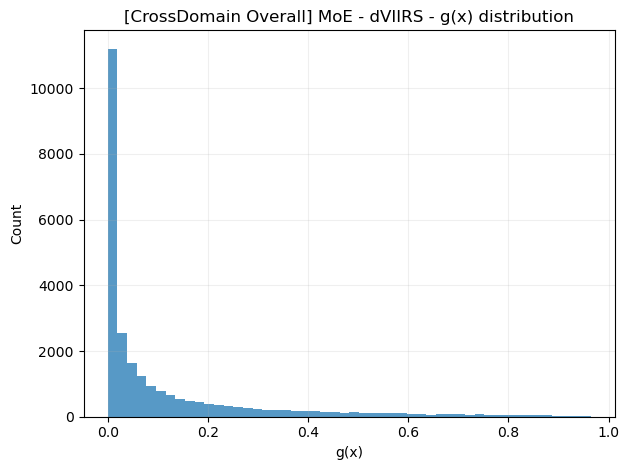

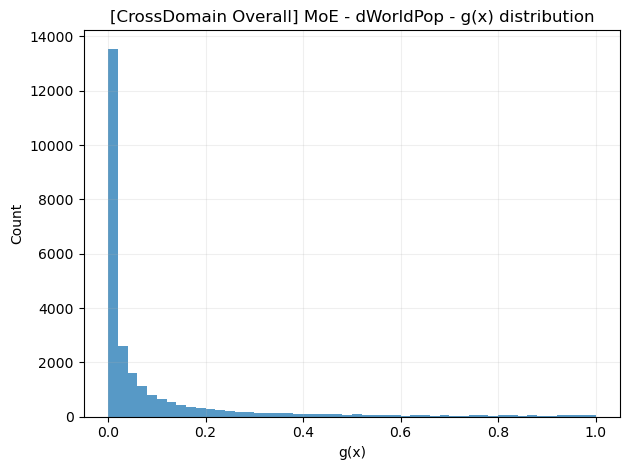

In [61]:

# 本 cell：为每个 split + target 生成关键图。
# 为什么：论文中常用 Random 与 GroupSplit 做代表性展示；cross-domain 展示 overall gating 分布用于诊断。

def run_plots_for_setting(split_name: str, target: str):
    arts = artifacts_all[(split_name, target)]

    art_xgb = arts['XGB']
    fig = plot_pred_vs_true(art_xgb.y_true, art_xgb.y_pred, art_xgb.tail_q05, art_xgb.tail_q95,
                            title=f'[{split_name}] XGB - {target}: Pred vs True')
    save_fig(fig, f"{safe(split_name)}__{safe(target)}__XGB__pred_true.png")

    for i, fig in enumerate(plot_residual_hist(art_xgb.y_true, art_xgb.y_pred, art_xgb.tail_q05, art_xgb.tail_q95,
                                               title=f'[{split_name}] XGB - {target}: Residuals')):
        save_fig(fig, f"{safe(split_name)}__{safe(target)}__XGB__resid_{i}.png")

    art_moe = arts['MoE_2expert']
    fig = plot_pred_vs_true(art_moe.y_true, art_moe.y_pred, art_moe.tail_q05, art_moe.tail_q95,
                            title=f'[{split_name}] MoE - {target}: Pred vs True')
    save_fig(fig, f"{safe(split_name)}__{safe(target)}__MoE__pred_true.png")

    for i, fig in enumerate(plot_residual_hist(art_moe.y_true, art_moe.y_pred, art_moe.tail_q05, art_moe.tail_q95,
                                               title=f'[{split_name}] MoE - {target}: Residuals')):
        save_fig(fig, f"{safe(split_name)}__{safe(target)}__MoE__resid_{i}.png")

    for i, fig in enumerate(plot_gating_diagnostics(art_moe, title_prefix=f'[{split_name}] MoE - {target}')):
        save_fig(fig, f"{safe(split_name)}__{safe(target)}__MoE__gating_{i}.png")


for target in target_cols:
    run_plots_for_setting('Random(70/15/15)', target)

if ('GroupSplit(grid_id)', target_cols[0]) in artifacts_all:
    for target in target_cols:
        run_plots_for_setting('GroupSplit(grid_id)', target)

for target in target_cols:
    if target in crossdomain_artifacts_for_plots:
        plot_gating_diagnostics(crossdomain_artifacts_for_plots[target], title_prefix=f'[CrossDomain Overall] MoE - {target}')


In [ ]:

# 本 cell：导出结果表到 CSV，方便论文直接引用与复现实验记录。
out_csv = '/mnt/data/transluxpop_moe_results_table.csv'
table.to_csv(out_csv, index=False)
print('Saved:', out_csv)



## 备注与可扩展点（建议写进论文/附录）
- 若你想进一步验证 “tail 是否真的能从 x 判断”，可以额外报告 gating 分类器在 test 上的 AUC/PR-AUC。
- 若你发现 gating 接近常数（分布集中在 0.5 附近），说明 tail 难以由 x 预测；此时 MoE 的收益更多来自 tail 变换，而不是 routing。
- 若想更贴合“哪个专家更可靠”的目标，可以把 gating 的监督从 “是否 tail” 改为 “tail expert 是否比 body expert 更准”（regret-based gating）。
